# AI Investment Signals

This notebook builds a stock direction model for AI-related companies.

Companies used: NVDA, MSFT, GOOGL, AMZN, AMD, and AVGO.

The target is whether a stock moves up over the next 7 trading days.


## Setup and Imports
Import libraries, set folder paths, create output folders, and set data refresh options.


In [1]:
import os
from pathlib import Path

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')

    possible_project_dirs = [
        Path('/content/MIS433-Final-Project'),
        Path('/content/drive/MyDrive/MIS_433_Project'),
        Path.cwd()
    ]

    PROJECT_DIR = None
    for folder in possible_project_dirs:
        if (folder / 'README.md').exists() or (folder / 'notebooks').exists():
            PROJECT_DIR = folder
            break

    if PROJECT_DIR is None:
        PROJECT_DIR = Path('/content/drive/MyDrive/MIS_433_Project')
        PROJECT_DIR.mkdir(parents=True, exist_ok=True)

    os.chdir(PROJECT_DIR)
    print(f"Running in Google Colab: {PROJECT_DIR}")
else:
    current_dir = Path.cwd().resolve()
    PROJECT_DIR = current_dir.parent if current_dir.name == 'notebooks' else current_dir
    os.chdir(PROJECT_DIR)
    print(f"Running locally in VS Code: {PROJECT_DIR}")

Path('data/raw').mkdir(parents=True, exist_ok=True)
Path('data/processed').mkdir(parents=True, exist_ok=True)
Path('data/external').mkdir(parents=True, exist_ok=True)
Path('outputs/charts').mkdir(parents=True, exist_ok=True)
Path('outputs/model_results').mkdir(parents=True, exist_ok=True)
Path('outputs/screenshots').mkdir(parents=True, exist_ok=True)


Running locally in VS Code: C:\Users\Carlos\Documents\MIS_433_Project


In [2]:
import subprocess
import sys

if IN_COLAB:
    packages = [
        "yfinance", "pandas", "numpy", "matplotlib", "seaborn",
        "scikit-learn", "requests", "python-dotenv", "google-generativeai"
    ]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + packages)
else:
    print("Using local Python environment.")


Using local Python environment.


In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_theme(style="whitegrid")

REFRESH_STOCK_DATA = False
REFRESH_SENTIMENT_DATA = False
print("Refresh stock data:", REFRESH_STOCK_DATA)
print("Refresh sentiment data:", REFRESH_SENTIMENT_DATA)


Refresh stock data: False
Refresh sentiment data: False


## Read the Stock Data
Load saved stock data. If `REFRESH_STOCK_DATA` is set to `True`, pull fresh stock data from Yahoo Finance.


In [4]:
tickers = ["NVDA", "MSFT", "GOOGL", "AMZN", "AMD", "AVGO"]
start_date = "2020-01-01"
end_date = datetime.today().strftime("%Y-%m-%d")


In [5]:
clean_stock_path = Path("data/processed/stock_prices_clean.csv")
raw_stock_path = Path("data/raw/stock_prices_raw.csv")
stock_data = None

if clean_stock_path.exists() and not REFRESH_STOCK_DATA:
    stock_df = pd.read_csv(clean_stock_path)
    stock_df["date"] = pd.to_datetime(stock_df["date"])
    print("Loaded saved clean stock data.")
else:
    stock_data = yf.download(
        tickers,
        start=start_date,
        end=end_date,
        auto_adjust=False,
        group_by="ticker"
    )
    stock_data.to_csv(raw_stock_path)
    print("Downloaded fresh stock data.")

stock_df.head() if "stock_df" in globals() else stock_data.head()


Loaded saved clean stock data.


,date,open,high,low,close,adj_close,volume,ticker
0,2020-01-02,5.96875,5.99775,5.91800,5.99775,5.970753,237536000,NVDA
1,2020-01-03,5.87750,5.94575,5.85250,5.90175,5.875187,205384000,NVDA
2,2020-01-06,5.80800,5.93175,5.78175,5.92650,5.899826,262636000,NVDA
3,2020-01-07,5.95500,6.04425,5.90975,5.99825,5.971252,314856000,NVDA
4,2020-01-08,5.99400,6.05100,5.95375,6.00950,5.982452,277108000,NVDA


In [6]:
if raw_stock_path.exists():
    print(f"Raw stock data file: {raw_stock_path}")
else:
    print("Raw stock data has not been saved yet.")


Raw stock data file: data\raw\stock_prices_raw.csv


## Clean and Format the Data
Convert the stock data into one table with one row per ticker and trading date.


In [7]:
if stock_data is not None:
    clean_data = []

    for ticker in tickers:
        temp = stock_data[ticker].copy()
        temp["ticker"] = ticker
        temp = temp.reset_index()
        clean_data.append(temp)

    stock_df = pd.concat(clean_data, ignore_index=True)
    stock_df.columns = [col.lower().replace(" ", "_") for col in stock_df.columns]
    stock_df["date"] = pd.to_datetime(stock_df["date"])
else:
    print("Using saved clean stock data.")

stock_df.head()


Using saved clean stock data.


,date,open,high,low,close,adj_close,volume,ticker
0,2020-01-02,5.96875,5.99775,5.91800,5.99775,5.970753,237536000,NVDA
1,2020-01-03,5.87750,5.94575,5.85250,5.90175,5.875187,205384000,NVDA
2,2020-01-06,5.80800,5.93175,5.78175,5.92650,5.899826,262636000,NVDA
3,2020-01-07,5.95500,6.04425,5.90975,5.99825,5.971252,314856000,NVDA
4,2020-01-08,5.99400,6.05100,5.95375,6.00950,5.982452,277108000,NVDA


In [8]:
stock_df.to_csv(clean_stock_path, index=False)
print(f"Saved clean stock data: {clean_stock_path}")


Saved clean stock data: data\processed\stock_prices_clean.csv


## Describe and Summarize the Data
Display the stock data, column information, summary statistics, and closing price chart.


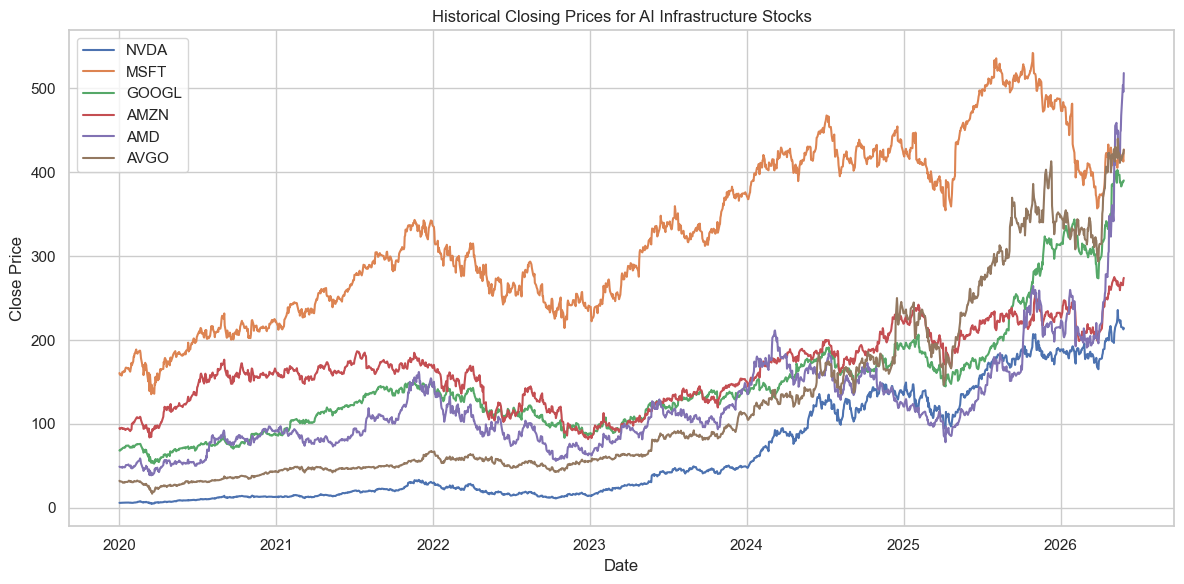

In [9]:
plt.figure(figsize=(12, 6))

for ticker in tickers:
    temp = stock_df[stock_df["ticker"] == ticker]
    plt.plot(temp["date"], temp["close"], label=ticker)

plt.title("Historical Closing Prices for AI Infrastructure Stocks")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
stock_df.info()
stock_df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9654 entries, 0 to 9653
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       9654 non-null   datetime64[ns]
 1   open       9654 non-null   float64       
 2   high       9654 non-null   float64       
 3   low        9654 non-null   float64       
 4   close      9654 non-null   float64       
 5   adj_close  9654 non-null   float64       
 6   volume     9654 non-null   int64         
 7   ticker     9654 non-null   object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 603.5+ KB


,date,open,high,low,close,adj_close,volume
count,9654,9654.000000,9654.000000,9654.000000,9654.000000,9654.000000,9.654000e+03
mean,2023-03-14 05:32:55.637041664,158.021590,160.080224,155.873339,158.052717,156.181640,1.007017e+08
min,2020-01-02 00:00:00,5.002500,5.248500,4.517000,4.910000,4.890823,4.123000e+06
25%,2021-08-06 00:00:00,79.263628,80.553499,77.782499,78.942501,78.553791,2.507675e+07
50%,2023-03-14 00:00:00,136.555000,138.430000,134.702995,136.409004,135.579445,3.951690e+07
75%,2024-10-17 00:00:00,206.994999,209.932499,203.452503,206.870003,203.179520,7.693380e+07
max,2026-05-28 00:00:00,555.229980,555.450012,540.770020,542.070007,538.658569,1.543911e+09
std,NaN,112.222682,113.283323,111.057496,112.240136,111.054420,1.561291e+08


## Create New Variables
Create return, moving average, volatility, and volume change columns.


In [11]:
stock_df = stock_df.sort_values(["ticker", "date"])

stock_df["daily_return"] = stock_df.groupby("ticker")["close"].pct_change()
stock_df["return_3d"] = stock_df.groupby("ticker")["close"].pct_change(3)
stock_df["return_5d"] = stock_df.groupby("ticker")["close"].pct_change(5)
stock_df["return_7d"] = stock_df.groupby("ticker")["close"].pct_change(7)
stock_df["return_10d"] = stock_df.groupby("ticker")["close"].pct_change(10)
stock_df["return_14d"] = stock_df.groupby("ticker")["close"].pct_change(14)
stock_df["return_30d"] = stock_df.groupby("ticker")["close"].pct_change(30)

stock_df["ma_7d"] = stock_df.groupby("ticker")["close"].transform(lambda x: x.rolling(window=7).mean())
stock_df["ma_14d"] = stock_df.groupby("ticker")["close"].transform(lambda x: x.rolling(window=14).mean())
stock_df["ma_30d"] = stock_df.groupby("ticker")["close"].transform(lambda x: x.rolling(window=30).mean())
stock_df["ma_90d"] = stock_df.groupby("ticker")["close"].transform(lambda x: x.rolling(window=90).mean())

stock_df["volatility_7d"] = stock_df.groupby("ticker")["daily_return"].transform(lambda x: x.rolling(window=7).std())
stock_df["volatility_14d"] = stock_df.groupby("ticker")["daily_return"].transform(lambda x: x.rolling(window=14).std())
stock_df["volatility_30d"] = stock_df.groupby("ticker")["daily_return"].transform(lambda x: x.rolling(window=30).std())

stock_df["volume_change"] = stock_df.groupby("ticker")["volume"].pct_change()
stock_df["avg_volume_30d"] = stock_df.groupby("ticker")["volume"].transform(lambda x: x.rolling(window=30).mean())
stock_df["volume_vs_avg_30d"] = stock_df["volume"] / stock_df["avg_volume_30d"]

stock_df["close_vs_ma_30d"] = (stock_df["close"] / stock_df["ma_30d"]) - 1
stock_df["ma_7d_vs_30d"] = (stock_df["ma_7d"] / stock_df["ma_30d"]) - 1

stock_df.head()


,date,open,high,low,close,adj_close,volume,ticker,daily_return,return_3d,...,ma_30d,ma_90d,volatility_7d,volatility_14d,volatility_30d,volume_change,avg_volume_30d,volume_vs_avg_30d,close_vs_ma_30d,ma_7d_vs_30d
6436,2020-01-02,46.860001,49.250000,46.630001,49.099998,49.099998,80331100,AMD,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6437,2020-01-03,48.029999,49.389999,47.540001,48.599998,48.599998,73127400,AMD,-0.010183,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.089675,NaN,NaN,NaN,NaN
6438,2020-01-06,48.020000,48.860001,47.860001,48.389999,48.389999,47934900,AMD,-0.004321,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.344502,NaN,NaN,NaN,NaN
6439,2020-01-07,49.349998,49.389999,48.040001,48.250000,48.250000,58061400,AMD,-0.002893,-0.017312,...,NaN,NaN,NaN,NaN,NaN,0.211255,NaN,NaN,NaN,NaN
6440,2020-01-08,47.849998,48.299999,47.139999,47.830002,47.830002,53767000,AMD,-0.008705,-0.015844,...,NaN,NaN,NaN,NaN,NaN,-0.073963,NaN,NaN,NaN,NaN


In [12]:
stock_df.to_csv("data/processed/stock_features.csv", index=False)


## Exploratory Data Analysis
Create charts and summary tables that compare stock performance, return, volatility, and volume.


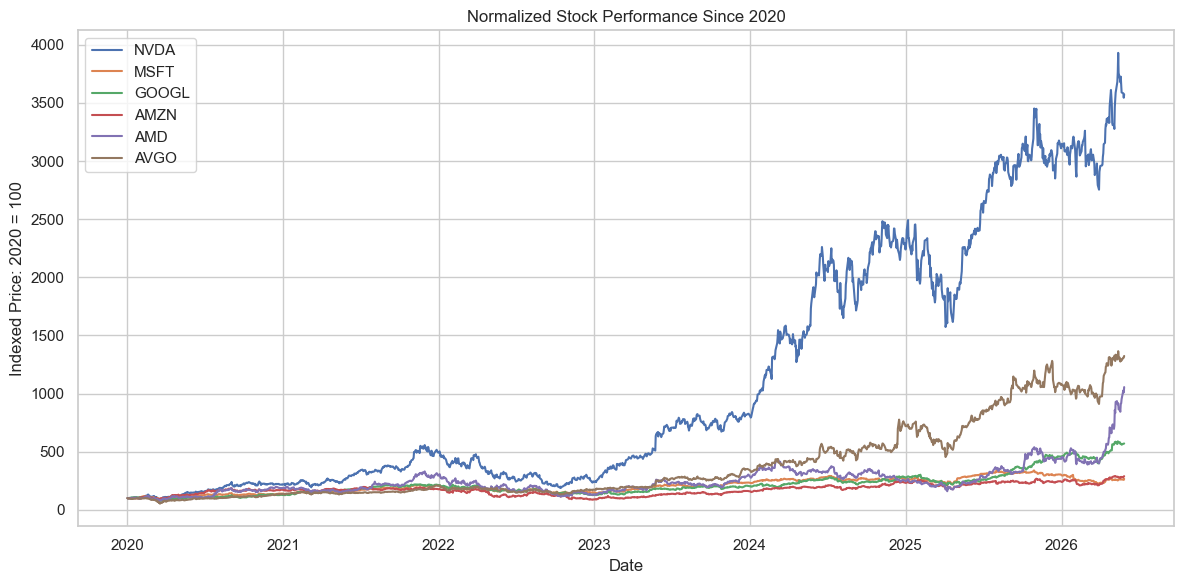

In [13]:
normalized_df = stock_df.copy()
normalized_df["normalized_close"] = normalized_df.groupby("ticker")["close"].transform(lambda x: x / x.iloc[0] * 100)

plt.figure(figsize=(12, 6))

for ticker in tickers:
    temp = normalized_df[normalized_df["ticker"] == ticker]
    plt.plot(temp["date"], temp["normalized_close"], label=ticker)

plt.title("Normalized Stock Performance Since 2020")
plt.xlabel("Date")
plt.ylabel("Indexed Price: 2020 = 100")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/charts/normalized_stock_performance.png", dpi=300, bbox_inches="tight")
plt.show()


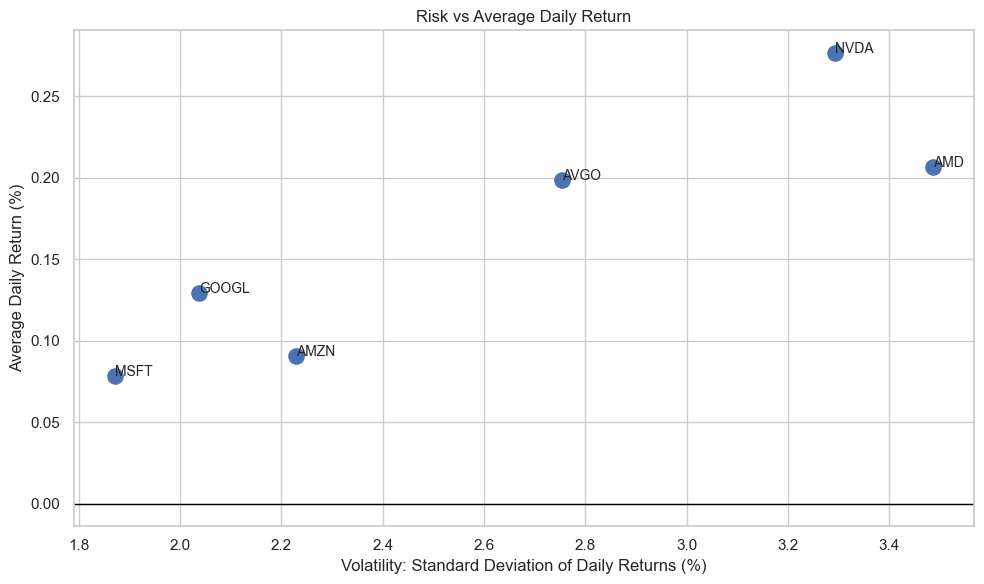

In [14]:
risk_return_summary = stock_df.groupby("ticker").agg(
    avg_daily_return=("daily_return", "mean"),
    volatility=("daily_return", "std"),
    avg_volume=("volume", "mean")
).reset_index()

risk_return_summary["avg_daily_return_pct"] = risk_return_summary["avg_daily_return"] * 100
risk_return_summary["volatility_pct"] = risk_return_summary["volatility"] * 100

plt.figure(figsize=(10, 6))
plt.scatter(
    risk_return_summary["volatility_pct"],
    risk_return_summary["avg_daily_return_pct"],
    s=120
)

for _, row in risk_return_summary.iterrows():
    plt.text(row["volatility_pct"], row["avg_daily_return_pct"], row["ticker"], fontsize=10)

plt.title("Risk vs Average Daily Return")
plt.xlabel("Volatility: Standard Deviation of Daily Returns (%)")
plt.ylabel("Average Daily Return (%)")
plt.axhline(0, color="black", linewidth=1)
plt.tight_layout()
plt.savefig("outputs/charts/risk_return_scatter.png", dpi=300, bbox_inches="tight")
plt.show()


In [15]:
summary = stock_df.groupby("ticker").agg(
    start_price=("close", "first"),
    end_price=("close", "last"),
    avg_daily_return=("daily_return", "mean"),
    volatility=("daily_return", "std"),
    avg_volume=("volume", "mean")
).reset_index()

summary["total_return"] = (summary["end_price"] / summary["start_price"]) - 1
summary = summary.sort_values("total_return", ascending=False)

summary


,ticker,start_price,end_price,avg_daily_return,volatility,avg_volume,total_return
5,NVDA,5.997750,214.250000,0.002765,0.032935,3.943177e+08,34.721730
2,AVGO,32.238998,426.579987,0.001985,0.027544,2.507557e+07,12.231800
0,AMD,49.099998,518.090027,0.002067,0.034863,5.980410e+07,9.551732
3,GOOGL,68.433998,390.130005,0.001290,0.020371,3.347338e+07,4.700821
1,AMZN,94.900497,274.000000,0.000907,0.022284,6.348480e+07,1.887235
4,MSFT,160.619995,426.989990,0.000783,0.018704,2.805469e+07,1.658386


## Read Sentiment Data
Load saved Alpha Vantage sentiment data. If `REFRESH_SENTIMENT_DATA` is set to `True`, pull fresh sentiment data.


In [16]:
import os
import requests
import time

daily_sentiment_path = Path("data/external/daily_sentiment_scores.csv")
raw_sentiment_path = Path("data/external/alpha_vantage_news_sentiment_raw.csv")
sentiment_df = pd.DataFrame()
using_saved_daily_sentiment = False

if daily_sentiment_path.exists() and not REFRESH_SENTIMENT_DATA:
    daily_sentiment = pd.read_csv(daily_sentiment_path)
    daily_sentiment["date"] = pd.to_datetime(daily_sentiment["date"], errors="coerce")
    using_saved_daily_sentiment = True
    print("Loaded saved daily sentiment scores.")
else:
    try:
        from google.colab import userdata
        alpha_key = userdata.get("ALPHA_VANTAGE_API_KEY")
    except ImportError:
        from dotenv import load_dotenv
        load_dotenv()
        alpha_key = os.getenv("ALPHA_VANTAGE_API_KEY")

    if not alpha_key:
        raise ValueError("Alpha Vantage API key not found. Add it to Colab Secrets or the local .env file.")

    all_sentiment = []

    for ticker in tickers:
        print(f"Pulling sentiment for {ticker}...")

        params = {
            "function": "NEWS_SENTIMENT",
            "tickers": ticker,
            "apikey": alpha_key,
            "limit": 50
        }

        response = requests.get("https://www.alphavantage.co/query", params=params, timeout=30)
        data = response.json()

        if "feed" not in data:
            print(f"No feed returned for {ticker}.")
            continue

        for article in data.get("feed", []):
            for ticker_info in article.get("ticker_sentiment", []):
                if ticker_info["ticker"] == ticker:
                    all_sentiment.append({
                        "ticker": ticker,
                        "date": article["time_published"][:8],
                        "title": article["title"],
                        "source": article["source"],
                        "url": article["url"],
                        "ticker_sentiment_score": float(ticker_info["ticker_sentiment_score"]),
                        "ticker_sentiment_label": ticker_info["ticker_sentiment_label"],
                        "relevance_score": float(ticker_info["relevance_score"])
                    })

        time.sleep(12)

    sentiment_df = pd.DataFrame(all_sentiment)

sentiment_df.head() if not sentiment_df.empty else daily_sentiment.head()


Loaded saved daily sentiment scores.


,ticker,date,avg_sentiment_score,avg_relevance_score,article_count
0,AMD,2026-05-27,0.155694,0.638067,19
1,AMD,2026-05-28,0.193455,0.665473,31
2,AMZN,2026-05-27,0.127651,0.736662,13
3,AMZN,2026-05-28,0.183193,0.731671,36
4,AMZN,2026-05-29,0.433087,1.000000,1


In [17]:
if using_saved_daily_sentiment:
    print("Using saved sentiment data for modeling.")
elif sentiment_df.empty:
    print("No new sentiment rows returned. Creating empty sentiment columns.")
    daily_sentiment = pd.DataFrame(columns=[
        "ticker", "date", "avg_sentiment_score", "avg_relevance_score", "article_count"
    ])
else:
    sentiment_df["date"] = pd.to_datetime(sentiment_df["date"], errors="coerce")
    daily_sentiment = sentiment_df.groupby(["ticker", "date"]).agg(
        avg_sentiment_score=("ticker_sentiment_score", "mean"),
        avg_relevance_score=("relevance_score", "mean"),
        article_count=("title", "count")
    ).reset_index()

daily_sentiment


Using saved sentiment data for modeling.


,ticker,date,avg_sentiment_score,avg_relevance_score,article_count
0,AMD,2026-05-27,0.155694,0.638067,19
1,AMD,2026-05-28,0.193455,0.665473,31
2,AMZN,2026-05-27,0.127651,0.736662,13
3,AMZN,2026-05-28,0.183193,0.731671,36
4,AMZN,2026-05-29,0.433087,1.000000,1
5,AVGO,2026-05-26,0.132127,0.634095,6
6,AVGO,2026-05-27,0.294311,0.759963,24
7,AVGO,2026-05-28,0.190800,0.609882,20
8,GOOGL,2026-05-27,0.128446,0.715441,23
9,GOOGL,2026-05-28,0.161826,0.687589,27


In [18]:
if not sentiment_df.empty and not using_saved_daily_sentiment:
    sentiment_df.to_csv(raw_sentiment_path, index=False)
    daily_sentiment.to_csv(daily_sentiment_path, index=False)
    print("Saved new sentiment files.")
else:
    print("No new sentiment files saved.")

daily_sentiment["ticker"].value_counts()


No new sentiment files saved.


ticker
AMZN     3
AVGO     3
AMD      2
GOOGL    2
MSFT     2
NVDA     1
Name: count, dtype: int64

## Data Integration: Merge Sentiment Data
Merge sentiment score, relevance score, and article count into the stock dataset.


In [19]:
latest_sentiment = daily_sentiment.sort_values("date").groupby("ticker").tail(1)

latest_sentiment = latest_sentiment[[
    "ticker",
    "avg_sentiment_score",
    "avg_relevance_score",
    "article_count"
]]

stock_df = pd.read_csv("data/processed/stock_features.csv")
stock_df["date"] = pd.to_datetime(stock_df["date"])

stock_df = stock_df.merge(latest_sentiment, on="ticker", how="left")

stock_df["avg_sentiment_score"] = stock_df["avg_sentiment_score"].fillna(0)
stock_df["avg_relevance_score"] = stock_df["avg_relevance_score"].fillna(0)
stock_df["article_count"] = stock_df["article_count"].fillna(0)

stock_df.head()


,date,open,high,low,close,adj_close,volume,ticker,daily_return,return_3d,...,volatility_14d,volatility_30d,volume_change,avg_volume_30d,volume_vs_avg_30d,close_vs_ma_30d,ma_7d_vs_30d,avg_sentiment_score,avg_relevance_score,article_count
0,2020-01-02,46.860001,49.250000,46.630001,49.099998,49.099998,80331100,AMD,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.193455,0.665473,31
1,2020-01-03,48.029999,49.389999,47.540001,48.599998,48.599998,73127400,AMD,-0.010183,NaN,...,NaN,NaN,-0.089675,NaN,NaN,NaN,NaN,0.193455,0.665473,31
2,2020-01-06,48.020000,48.860001,47.860001,48.389999,48.389999,47934900,AMD,-0.004321,NaN,...,NaN,NaN,-0.344502,NaN,NaN,NaN,NaN,0.193455,0.665473,31
3,2020-01-07,49.349998,49.389999,48.040001,48.250000,48.250000,58061400,AMD,-0.002893,-0.017312,...,NaN,NaN,0.211255,NaN,NaN,NaN,NaN,0.193455,0.665473,31
4,2020-01-08,47.849998,48.299999,47.139999,47.830002,47.830002,53767000,AMD,-0.008705,-0.015844,...,NaN,NaN,-0.073963,NaN,NaN,NaN,NaN,0.193455,0.665473,31


In [20]:
stock_df.to_csv("data/processed/stock_features_with_sentiment.csv", index=False)


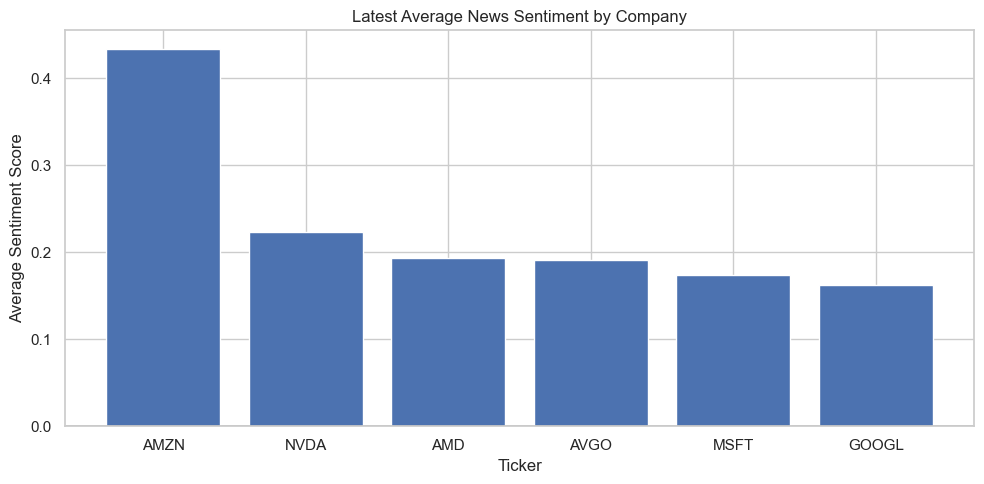

In [21]:
sentiment_summary = latest_sentiment.sort_values("avg_sentiment_score", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(sentiment_summary["ticker"], sentiment_summary["avg_sentiment_score"])
plt.title("Latest Average News Sentiment by Company")
plt.xlabel("Ticker")
plt.ylabel("Average Sentiment Score")
plt.axhline(0, color="black", linewidth=1)
plt.tight_layout()
plt.savefig("outputs/charts/latest_sentiment_by_company.png", dpi=300, bbox_inches="tight")
plt.show()


## Preprocessing: Create the Target Variable
Create future return columns and target columns.

The main target is `target_up_7d`. A value of `1` means the stock rose more than the cutoff over the next 7 trading days. A value of `0` means it did not.


In [22]:
stock_df = pd.read_csv("data/processed/stock_features_with_sentiment.csv")
stock_df["date"] = pd.to_datetime(stock_df["date"])
stock_df = stock_df.sort_values(["ticker", "date"])

prediction_windows = [3, 5, 7, 10]

for window in prediction_windows:
    stock_df[f"future_close_{window}d"] = stock_df.groupby("ticker")["close"].shift(-window)
    stock_df[f"future_return_{window}d"] = (stock_df[f"future_close_{window}d"] / stock_df["close"]) - 1
    stock_df[f"target_up_{window}d"] = (stock_df[f"future_return_{window}d"] > 0).where(
        stock_df[f"future_close_{window}d"].notna()
    )
    stock_df[f"target_up_{window}d"] = stock_df[f"target_up_{window}d"].astype("Int64")

feature_columns = [
    "daily_return", "return_3d", "return_5d", "return_7d", "return_10d", "return_14d", "return_30d",
    "ma_7d", "ma_14d", "ma_30d", "ma_90d", "ma_7d_vs_30d", "close_vs_ma_30d",
    "volatility_7d", "volatility_14d", "volatility_30d",
    "volume_change", "volume_vs_avg_30d", "avg_sentiment_score", "article_count"
]

training_df = stock_df.dropna(subset=feature_columns + ["target_up_7d"]).copy()
training_df["target_up_7d"] = training_df["target_up_7d"].astype(int)

unknown_future_df = stock_df[stock_df["target_up_7d"].isna()].copy()
latest_prediction_df = unknown_future_df.sort_values(["ticker", "date"]).groupby("ticker").tail(1)

print(f"Model-ready rows: {len(stock_df)}")
print(f"Training rows with known 7-day target: {len(training_df)}")
print(f"Current prediction rows: {len(latest_prediction_df)}")

stock_df[[
    "date", "ticker", "close", "future_close_3d", "future_close_5d",
    "future_close_7d", "future_close_10d", "future_return_7d", "target_up_7d"
]].head(10)


Model-ready rows: 9654
Training rows with known 7-day target: 9078
Current prediction rows: 6


,date,ticker,close,future_close_3d,future_close_5d,future_close_7d,future_close_10d,future_return_7d,target_up_7d
0,2020-01-02,AMD,49.099998,48.250000,48.970001,48.750000,49.770000,-0.007128,0
1,2020-01-03,AMD,48.599998,47.830002,48.169998,48.209999,50.930000,-0.008025,0
2,2020-01-06,AMD,48.389999,48.970001,48.750000,48.549999,51.049999,0.003306,1
3,2020-01-07,AMD,48.250000,48.169998,48.209999,49.770000,51.430000,0.031503,1
4,2020-01-08,AMD,47.830002,48.750000,48.549999,50.930000,51.709999,0.064813,1
5,2020-01-09,AMD,48.970001,48.209999,49.770000,51.049999,50.349998,0.042475,1
6,2020-01-10,AMD,48.169998,48.549999,50.930000,51.430000,49.259998,0.067677,1
7,2020-01-13,AMD,48.750000,49.770000,51.049999,51.709999,50.529999,0.060718,1
8,2020-01-14,AMD,48.209999,50.930000,51.430000,50.349998,47.509998,0.044389,1
9,2020-01-15,AMD,48.549999,51.049999,51.709999,49.259998,48.779999,0.014624,1


In [23]:
stock_df.to_csv("data/processed/model_ready_stock_data.csv", index=False)
training_df.to_csv("data/processed/training_ready_stock_data.csv", index=False)
latest_prediction_df.to_csv("data/processed/latest_prediction_rows.csv", index=False)


## Exploratory Analysis: Variables Compared to Target
Compare selected variables against `target_up_7d` before modeling.


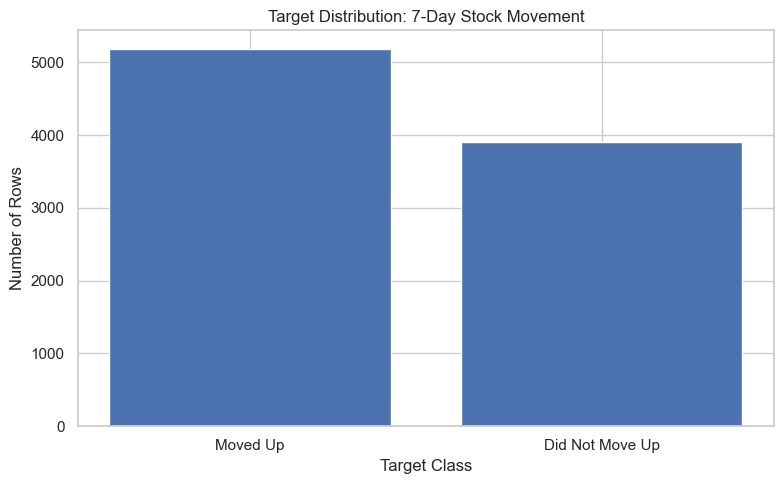

target_label
Moved Up           5179
Did Not Move Up    3899
Name: count, dtype: int64

In [24]:
target_eda_df = training_df.copy()
target_eda_df["target_label"] = target_eda_df["target_up_7d"].map({
    0: "Did Not Move Up",
    1: "Moved Up"
})

target_counts = target_eda_df["target_label"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(target_counts.index, target_counts.values)
plt.title("Target Distribution: 7-Day Stock Movement")
plt.xlabel("Target Class")
plt.ylabel("Number of Rows")
plt.tight_layout()
plt.savefig("outputs/charts/target_distribution_7d.png", dpi=300, bbox_inches="tight")
plt.show()

target_counts


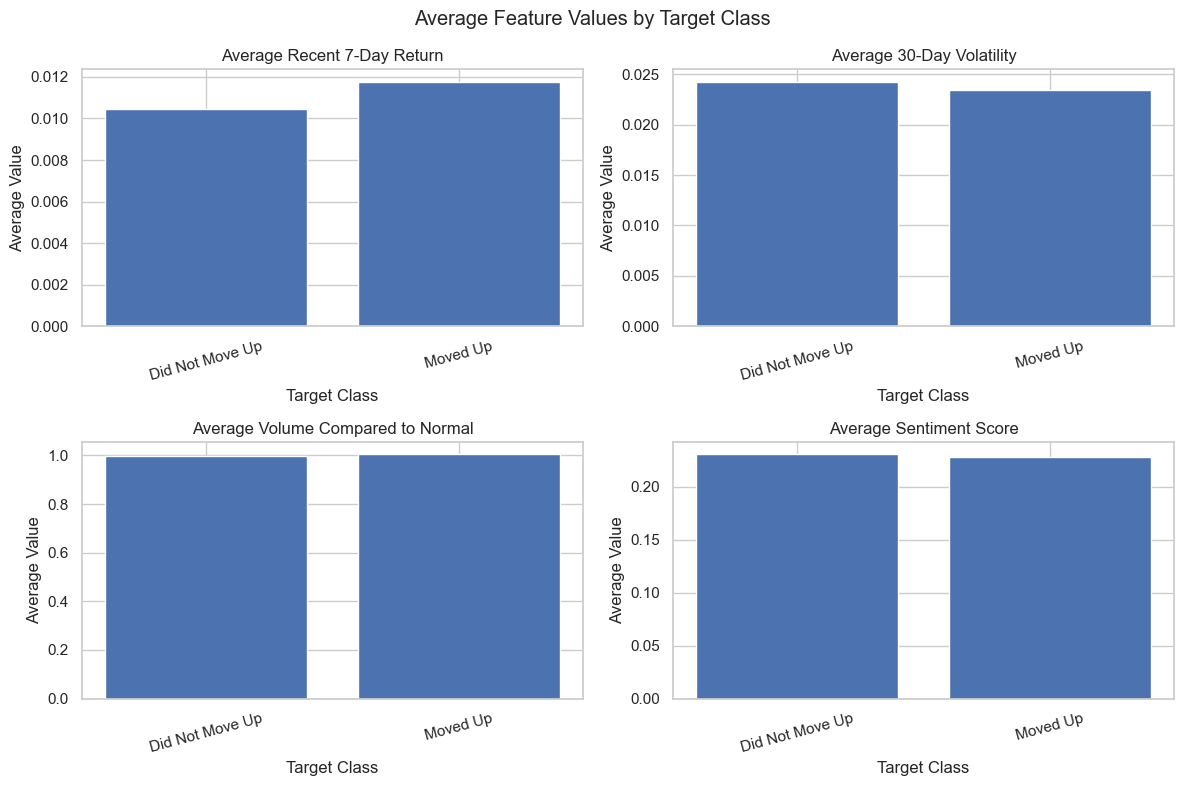

,target_label,avg_recent_return,avg_volatility,avg_volume_vs_normal,avg_sentiment
0,Did Not Move Up,0.010454,0.024283,0.997911,0.230938
1,Moved Up,0.011775,0.023413,1.005574,0.228252


In [25]:
target_feature_summary = target_eda_df.groupby("target_label").agg(
    avg_recent_return=("return_7d", "mean"),
    avg_volatility=("volatility_30d", "mean"),
    avg_volume_vs_normal=("volume_vs_avg_30d", "mean"),
    avg_sentiment=("avg_sentiment_score", "mean")
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
charts = [
    ("avg_recent_return", "Average Recent 7-Day Return"),
    ("avg_volatility", "Average 30-Day Volatility"),
    ("avg_volume_vs_normal", "Average Volume Compared to Normal"),
    ("avg_sentiment", "Average Sentiment Score")
]

for ax, (column, title) in zip(axes.flatten(), charts):
    ax.bar(target_feature_summary["target_label"], target_feature_summary[column])
    ax.set_title(title)
    ax.set_xlabel("Target Class")
    ax.set_ylabel("Average Value")
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Average Feature Values by Target Class")
plt.tight_layout()
plt.savefig("outputs/charts/target_feature_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

target_feature_summary


## Build and Compare Models
Train and test Logistic Regression, Decision Tree, and Random Forest models.

The models use historical rows where the future 7-day result is already known.

The model with the highest balanced accuracy is selected.


In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

model_df = pd.read_csv("data/processed/model_ready_stock_data.csv")
model_df["date"] = pd.to_datetime(model_df["date"])
model_df = model_df.sort_values(["date", "ticker"])

feature_groups = {
    "price_volume_only": [
        "daily_return", "return_3d", "return_5d", "return_7d", "return_10d", "return_14d", "return_30d",
        "ma_7d", "ma_14d", "ma_30d", "ma_90d", "ma_7d_vs_30d", "close_vs_ma_30d",
        "volatility_7d", "volatility_14d", "volatility_30d",
        "volume_change", "volume_vs_avg_30d", "ticker"
    ],
    "price_volume_sentiment": [
        "daily_return", "return_3d", "return_5d", "return_7d", "return_10d", "return_14d", "return_30d",
        "ma_7d", "ma_14d", "ma_30d", "ma_90d", "ma_7d_vs_30d", "close_vs_ma_30d",
        "volatility_7d", "volatility_14d", "volatility_30d",
        "volume_change", "volume_vs_avg_30d", "avg_sentiment_score", "article_count", "ticker"
    ],
    "short_term_signals": [
        "daily_return", "return_3d", "return_5d", "return_7d", "return_10d",
        "volatility_7d", "volatility_14d", "volume_change", "volume_vs_avg_30d",
        "avg_sentiment_score", "article_count", "ticker"
    ],
    "trend_signals": [
        "return_7d", "return_14d", "return_30d", "ma_7d_vs_30d", "close_vs_ma_30d",
        "volatility_30d", "volume_vs_avg_30d", "avg_sentiment_score", "ticker"
    ]
}

print(f"Rows available before modeling: {len(model_df)}")
print("Date range:", model_df["date"].min().date(), "to", model_df["date"].max().date())
print("Feature groups tested:")
for name, columns in feature_groups.items():
    print(f"- {name}: {len(columns)} features")


Rows available before modeling: 9654
Date range: 2020-01-02 to 2026-05-28
Feature groups tested:
- price_volume_only: 19 features
- price_volume_sentiment: 21 features
- short_term_signals: 12 features
- trend_signals: 9 features


In [27]:
def make_preprocessor(feature_columns, scale_numeric=False):
    numeric_columns = [col for col in feature_columns if col != "ticker"]
    numeric_step = StandardScaler() if scale_numeric else "passthrough"

    return ColumnTransformer([
        ("numeric", numeric_step, numeric_columns),
        ("ticker", OneHotEncoder(handle_unknown="ignore"), ["ticker"])
    ])

def predict_with_threshold(model, X, threshold=None):
    if threshold is None or not hasattr(model, "predict_proba"):
        return model.predict(X)

    probabilities = model.predict_proba(X)[:, 1]
    return (probabilities >= threshold).astype(int)

def evaluate_model_versions(data, feature_groups):
    rows = []
    trained_models = {}

    prediction_windows = [7]
    movement_cutoffs = [0.005]
    probability_thresholds = [0.40, 0.43, 0.45, 0.50]

    for window in prediction_windows:
        future_return_column = f"future_return_{window}d"

        for cutoff in movement_cutoffs:
            cutoff_df = data.dropna(subset=[future_return_column]).copy()
            cutoff_df = cutoff_df[cutoff_df[future_return_column].abs() >= cutoff].copy()
            cutoff_df["target_up"] = (cutoff_df[future_return_column] > cutoff).astype(int)

            for feature_group_name, feature_columns in feature_groups.items():
                model_data = cutoff_df.dropna(subset=feature_columns + ["target_up"]).copy()
                model_data = model_data.sort_values(["date", "ticker"])

                split_date = model_data["date"].quantile(0.80)
                train_df = model_data[model_data["date"] <= split_date].copy()
                test_df = model_data[model_data["date"] > split_date].copy()

                X_train = train_df[feature_columns]
                y_train = train_df["target_up"]
                X_test = test_df[feature_columns]
                y_test = test_df["target_up"]

                model_options = [
                    ("Baseline Majority Class", "most_frequent", DummyClassifier(strategy="most_frequent"), [None]),
                    ("Logistic Regression", "C=0.5", Pipeline([
                        ("preprocessor", make_preprocessor(feature_columns, scale_numeric=True)),
                        ("model", LogisticRegression(C=0.5, max_iter=1000, class_weight="balanced", random_state=42))
                    ]), probability_thresholds),
                    ("Logistic Regression", "C=1", Pipeline([
                        ("preprocessor", make_preprocessor(feature_columns, scale_numeric=True)),
                        ("model", LogisticRegression(C=1, max_iter=1000, class_weight="balanced", random_state=42))
                    ]), probability_thresholds),
                    ("Decision Tree", "max_depth=3, min_samples_leaf=10", Pipeline([
                        ("preprocessor", make_preprocessor(feature_columns)),
                        ("model", DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, class_weight="balanced", random_state=42))
                    ]), probability_thresholds),
                    ("Decision Tree", "max_depth=4, min_samples_leaf=10", Pipeline([
                        ("preprocessor", make_preprocessor(feature_columns)),
                        ("model", DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, class_weight="balanced", random_state=42))
                    ]), probability_thresholds),
                    ("Decision Tree", "max_depth=5, min_samples_leaf=20", Pipeline([
                        ("preprocessor", make_preprocessor(feature_columns)),
                        ("model", DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, class_weight="balanced", random_state=42))
                    ]), probability_thresholds),
                    ("Random Forest", "n_estimators=100, max_depth=3, min_samples_leaf=5", Pipeline([
                        ("preprocessor", make_preprocessor(feature_columns)),
                        ("model", RandomForestClassifier(n_estimators=100, max_depth=3, min_samples_leaf=5, class_weight="balanced", random_state=42, n_jobs=-1))
                    ]), probability_thresholds),
                    ("Random Forest", "n_estimators=100, max_depth=5, min_samples_leaf=10", Pipeline([
                        ("preprocessor", make_preprocessor(feature_columns)),
                        ("model", RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=10, class_weight="balanced", random_state=42, n_jobs=-1))
                    ]), probability_thresholds)
                ]

                for model_name, settings, model, thresholds in model_options:
                    model.fit(X_train, y_train)

                    for threshold in thresholds:
                        predictions = predict_with_threshold(model, X_test, threshold)
                        model_key = f"{window}d|{feature_group_name}|{cutoff}|{model_name}|{settings}"
                        trained_models[model_key] = {
                            "model": model,
                            "feature_columns": feature_columns,
                            "window": window,
                            "cutoff": cutoff,
                            "feature_group": feature_group_name,
                            "settings": settings,
                            "split_date": split_date,
                            "train_df": train_df,
                            "test_df": test_df,
                            "X_test": X_test,
                            "y_test": y_test
                        }

                        rows.append({
                            "model_key": model_key,
                            "prediction_window": window,
                            "feature_group": feature_group_name,
                            "target_cutoff": cutoff,
                            "model": model_name,
                            "settings": settings,
                            "threshold": "default" if threshold is None else threshold,
                            "accuracy": accuracy_score(y_test, predictions),
                            "balanced_accuracy": balanced_accuracy_score(y_test, predictions),
                            "f1_up": f1_score(y_test, predictions),
                            "train_rows": len(train_df),
                            "test_rows": len(test_df),
                            "split_date": split_date.date()
                        })

    results = pd.DataFrame(rows).sort_values("balanced_accuracy", ascending=False)
    return results, trained_models

results_df, trained_models = evaluate_model_versions(model_df, feature_groups)
results_df.head(20)


,model_key,prediction_window,feature_group,target_cutoff,model,settings,threshold,accuracy,balanced_accuracy,f1_up,train_rows,test_rows,split_date
52,7d|price_volume_sentiment|0.005|Random Forest|...,7,price_volume_sentiment,0.005,Random Forest,"n_estimators=100, max_depth=3, min_samples_leaf=5",0.45,0.583383,0.545748,0.676566,6703,1673,2025-03-04
23,7d|price_volume_only|0.005|Random Forest|n_est...,7,price_volume_only,0.005,Random Forest,"n_estimators=100, max_depth=3, min_samples_leaf=5",0.45,0.585774,0.540766,0.685714,6703,1673,2025-03-04
40,7d|price_volume_sentiment|0.005|Decision Tree|...,7,price_volume_sentiment,0.005,Decision Tree,"max_depth=3, min_samples_leaf=10",0.45,0.508069,0.533576,0.517302,6703,1673,2025-03-04
11,7d|price_volume_only|0.005|Decision Tree|max_d...,7,price_volume_only,0.005,Decision Tree,"max_depth=3, min_samples_leaf=10",0.45,0.508069,0.533576,0.517302,6703,1673,2025-03-04
55,7d|price_volume_sentiment|0.005|Random Forest|...,7,price_volume_sentiment,0.005,Random Forest,"n_estimators=100, max_depth=5, min_samples_lea...",0.43,0.549313,0.530837,0.625621,6703,1673,2025-03-04
2,7d|price_volume_only|0.005|Logistic Regression...,7,price_volume_only,0.005,Logistic Regression,C=0.5,0.43,0.473999,0.530089,0.408602,6703,1673,2025-03-04
31,7d|price_volume_sentiment|0.005|Logistic Regre...,7,price_volume_sentiment,0.005,Logistic Regression,C=0.5,0.43,0.473401,0.529606,0.407532,6703,1673,2025-03-04
21,7d|price_volume_only|0.005|Random Forest|n_est...,7,price_volume_only,0.005,Random Forest,"n_estimators=100, max_depth=3, min_samples_leaf=5",0.4,0.624626,0.528579,0.754687,6703,1673,2025-03-04
54,7d|price_volume_sentiment|0.005|Random Forest|...,7,price_volume_sentiment,0.005,Random Forest,"n_estimators=100, max_depth=5, min_samples_lea...",0.4,0.589958,0.528516,0.703800,6703,1673,2025-03-04
6,7d|price_volume_only|0.005|Logistic Regression...,7,price_volume_only,0.005,Logistic Regression,C=1,0.43,0.471010,0.528274,0.401623,6703,1673,2025-03-04


Selected model: Random Forest
Prediction window: 7
Feature group: price_volume_sentiment
Settings: n_estimators=100, max_depth=3, min_samples_leaf=5
Target cutoff: 0.005
Selected threshold: 0.45
Accuracy: 0.583
Balanced accuracy: 0.546
Confusion matrix:
[[247 391]
 [306 729]]
Classification report:
              precision    recall  f1-score   support

           0       0.45      0.39      0.41       638
           1       0.65      0.70      0.68      1035

    accuracy                           0.58      1673
   macro avg       0.55      0.55      0.55      1673
weighted avg       0.57      0.58      0.58      1673



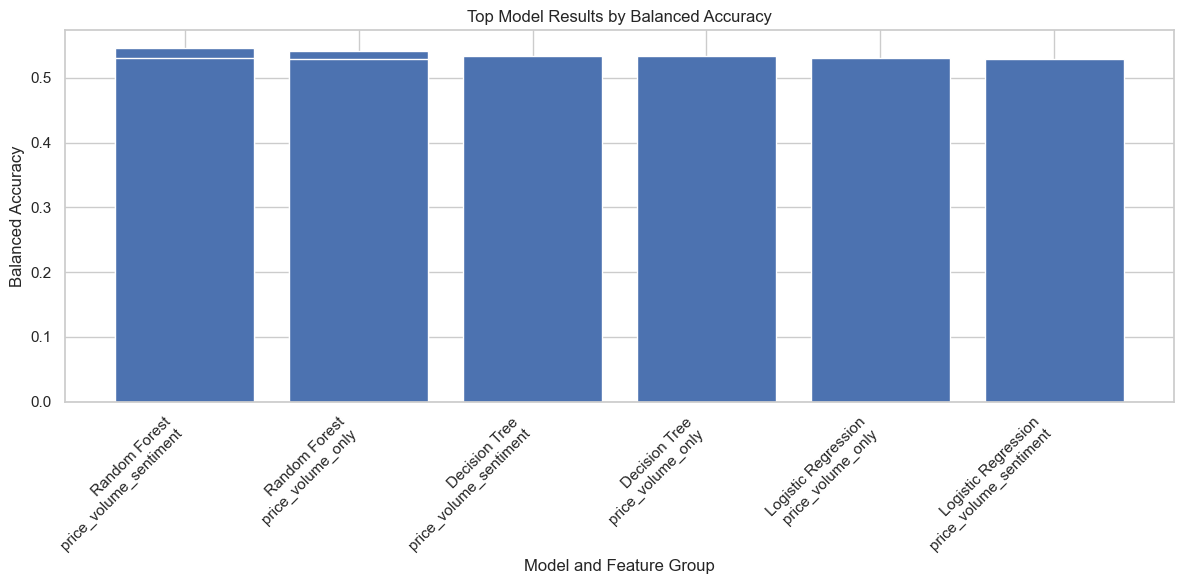

,model_key,prediction_window,feature_group,target_cutoff,model,settings,threshold,accuracy,balanced_accuracy,f1_up,train_rows,test_rows,split_date
52,7d|price_volume_sentiment|0.005|Random Forest|...,7,price_volume_sentiment,0.005,Random Forest,"n_estimators=100, max_depth=3, min_samples_leaf=5",0.45,0.583383,0.545748,0.676566,6703,1673,2025-03-04
23,7d|price_volume_only|0.005|Random Forest|n_est...,7,price_volume_only,0.005,Random Forest,"n_estimators=100, max_depth=3, min_samples_leaf=5",0.45,0.585774,0.540766,0.685714,6703,1673,2025-03-04
40,7d|price_volume_sentiment|0.005|Decision Tree|...,7,price_volume_sentiment,0.005,Decision Tree,"max_depth=3, min_samples_leaf=10",0.45,0.508069,0.533576,0.517302,6703,1673,2025-03-04
11,7d|price_volume_only|0.005|Decision Tree|max_d...,7,price_volume_only,0.005,Decision Tree,"max_depth=3, min_samples_leaf=10",0.45,0.508069,0.533576,0.517302,6703,1673,2025-03-04
55,7d|price_volume_sentiment|0.005|Random Forest|...,7,price_volume_sentiment,0.005,Random Forest,"n_estimators=100, max_depth=5, min_samples_lea...",0.43,0.549313,0.530837,0.625621,6703,1673,2025-03-04
2,7d|price_volume_only|0.005|Logistic Regression...,7,price_volume_only,0.005,Logistic Regression,C=0.5,0.43,0.473999,0.530089,0.408602,6703,1673,2025-03-04
31,7d|price_volume_sentiment|0.005|Logistic Regre...,7,price_volume_sentiment,0.005,Logistic Regression,C=0.5,0.43,0.473401,0.529606,0.407532,6703,1673,2025-03-04
21,7d|price_volume_only|0.005|Random Forest|n_est...,7,price_volume_only,0.005,Random Forest,"n_estimators=100, max_depth=3, min_samples_leaf=5",0.4,0.624626,0.528579,0.754687,6703,1673,2025-03-04
54,7d|price_volume_sentiment|0.005|Random Forest|...,7,price_volume_sentiment,0.005,Random Forest,"n_estimators=100, max_depth=5, min_samples_lea...",0.4,0.589958,0.528516,0.703800,6703,1673,2025-03-04
6,7d|price_volume_only|0.005|Logistic Regression...,7,price_volume_only,0.005,Logistic Regression,C=1,0.43,0.471010,0.528274,0.401623,6703,1673,2025-03-04


In [28]:
model_candidates = results_df[results_df["model"] != "Baseline Majority Class"].copy()
best_result = model_candidates.iloc[0]

best_model_key = best_result["model_key"]
best_model_info = trained_models[best_model_key]
best_model = best_model_info["model"]
best_feature_columns = best_model_info["feature_columns"]
best_window = int(best_model_info["window"])
best_threshold = best_result["threshold"]
best_threshold = None if best_threshold == "default" else float(best_threshold)

X_test = best_model_info["X_test"]
y_test = best_model_info["y_test"]
test_df = best_model_info["test_df"]
best_predictions = predict_with_threshold(best_model, X_test, best_threshold)

print("Selected model:", best_result["model"])
print("Prediction window:", best_window)
print("Feature group:", best_result["feature_group"])
print("Settings:", best_result["settings"])
print("Target cutoff:", best_result["target_cutoff"])
print("Selected threshold:", "default" if best_threshold is None else best_threshold)
print("Accuracy:", round(accuracy_score(y_test, best_predictions), 3))
print("Balanced accuracy:", round(balanced_accuracy_score(y_test, best_predictions), 3))
print("Confusion matrix:")
print(confusion_matrix(y_test, best_predictions))
print("Classification report:")
print(classification_report(y_test, best_predictions))

test_predictions_df = test_df[["date", "ticker", "close", f"future_return_{best_window}d", "target_up"]].copy()
test_predictions_df["predicted_up"] = best_predictions

if hasattr(best_model, "predict_proba"):
    test_predictions_df["prediction_probability_up"] = best_model.predict_proba(X_test)[:, 1]

results_df.to_csv("outputs/model_results/model_comparison.csv", index=False)
test_predictions_df.to_csv("outputs/model_results/test_set_predictions.csv", index=False)

model_chart_df = results_df[results_df["model"] != "Baseline Majority Class"].head(8).copy()
model_chart_df["model_label"] = model_chart_df["model"] + "\n" + model_chart_df["feature_group"]

plt.figure(figsize=(12, 6))
plt.bar(model_chart_df["model_label"], model_chart_df["balanced_accuracy"])
plt.title("Top Model Results by Balanced Accuracy")
plt.xlabel("Model and Feature Group")
plt.ylabel("Balanced Accuracy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("outputs/charts/model_comparison_balanced_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

results_df.head(10)


## Review the Selected Model
Display the selected model results and feature importance values.


In [29]:
print("Selected model for final predictions:")
print(best_result[["prediction_window", "model", "settings", "threshold", "accuracy", "balanced_accuracy", "f1_up"]])


Selected model for final predictions:
prediction_window                                                    7
model                                                    Random Forest
settings             n_estimators=100, max_depth=3, min_samples_leaf=5
threshold                                                         0.45
accuracy                                                      0.583383
balanced_accuracy                                             0.545748
f1_up                                                         0.676566
Name: 52, dtype: object


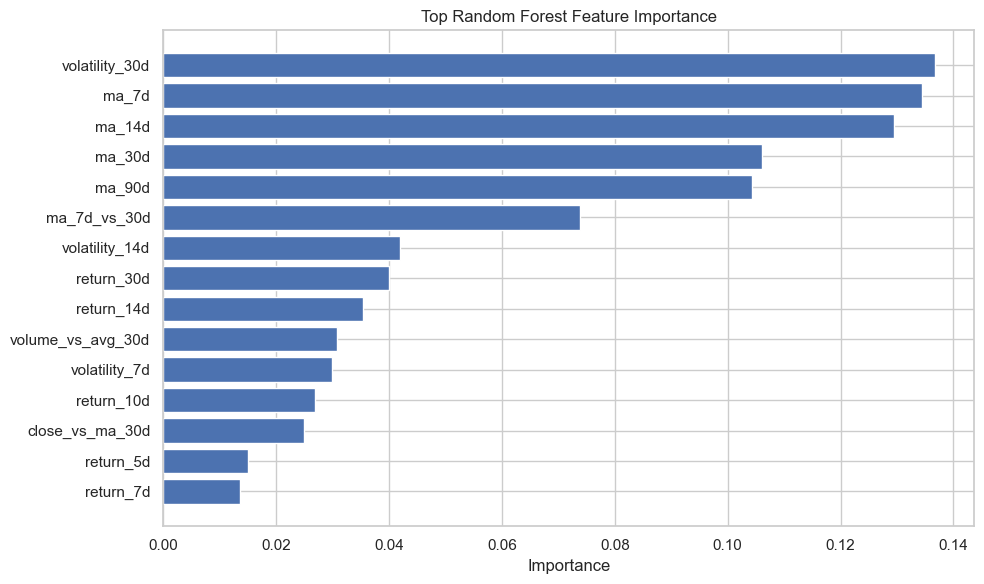

,feature,importance
15,volatility_30d,0.136804
7,ma_7d,0.134444
8,ma_14d,0.129407
9,ma_30d,0.106118
10,ma_90d,0.104246
11,ma_7d_vs_30d,0.073861
14,volatility_14d,0.041836
6,return_30d,0.039910
5,return_14d,0.035342
17,volume_vs_avg_30d,0.030691


In [30]:
selected_estimator = best_model.named_steps["model"]
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
feature_names = [name.replace("numeric__", "").replace("ticker__", "ticker_") for name in feature_names]

if hasattr(selected_estimator, "feature_importances_"):
    importance_values = selected_estimator.feature_importances_
    importance_label = "importance"
elif hasattr(selected_estimator, "coef_"):
    importance_values = abs(selected_estimator.coef_[0])
    importance_label = "absolute_coefficient"
else:
    importance_values = np.zeros(len(feature_names))
    importance_label = "importance"

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    importance_label: importance_values
}).sort_values(importance_label, ascending=True)

top_features_df = feature_importance_df.tail(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features_df["feature"], top_features_df[importance_label])
plt.title(f"Top {best_result['model']} Feature Importance")
plt.xlabel(importance_label.replace("_", " ").title())
plt.tight_layout()
plt.savefig("outputs/charts/model_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

feature_importance_df.to_csv("outputs/model_results/model_feature_importance.csv", index=False)
feature_importance_df.sort_values(importance_label, ascending=False)


## Current Prediction Output
Apply the selected model to the newest row for each company.

These rows are not used for training because the future 7-day result is not known yet. The output includes the prediction signal, probability, sentiment score, and article count.


In [31]:
latest_df = pd.read_csv("data/processed/latest_prediction_rows.csv")
latest_df["date"] = pd.to_datetime(latest_df["date"])
latest_features = latest_df.dropna(subset=best_feature_columns).copy()

latest_predictions = predict_with_threshold(best_model, latest_features[best_feature_columns], best_threshold)
latest_output_columns = ["date", "ticker", "close", "avg_sentiment_score", "article_count"]
latest_output = latest_features[latest_output_columns].copy()
latest_output["prediction_window_days"] = best_window
latest_output["predicted_up"] = latest_predictions
latest_output["prediction_signal"] = latest_output["predicted_up"].map({1: "Positive Signal", 0: "Caution"})
latest_output["target_cutoff_used"] = best_result["target_cutoff"]

if hasattr(best_model, "predict_proba"):
    latest_output["prediction_probability_up"] = best_model.predict_proba(latest_features[best_feature_columns])[:, 1]

latest_output = latest_output.sort_values("prediction_probability_up", ascending=False)
latest_output.to_csv("outputs/model_results/latest_direction_predictions.csv", index=False)
latest_output


,date,ticker,close,avg_sentiment_score,article_count,prediction_window_days,predicted_up,prediction_signal,target_cutoff_used,prediction_probability_up
1,2026-05-28,AMZN,274.000000,0.433087,1,7,1,Positive Signal,0.005,0.520584
4,2026-05-28,MSFT,426.989990,0.173975,47,7,1,Positive Signal,0.005,0.494745
3,2026-05-28,GOOGL,390.130005,0.161826,27,7,1,Positive Signal,0.005,0.473169
2,2026-05-28,AVGO,426.579987,0.190800,20,7,1,Positive Signal,0.005,0.467505
5,2026-05-28,NVDA,214.250000,0.223289,50,7,1,Positive Signal,0.005,0.464089
0,2026-05-28,AMD,518.090027,0.193455,31,7,0,Caution,0.005,0.380890
